<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/ReinforcementLearningAndDecisionMaking/ReinforcementLearningAndDecisionMaking/Online_Learning_Agent_and_Failure_Analysis_of_RL_Strategies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import gymnasium as gym
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import yfinance as yf

In [2]:
# --- CONFIGURATION ---
TICKER = "BTC-USD"
TRAIN_START = "2018-01-01"
TRAIN_END = "2022-01-01"  # Pre-training Cutoff
TEST_START = "2022-01-02"
TEST_END = "2024-01-01"    # The "Live" Phase
UPDATE_INTERVAL = 64       # Agent learns every 64 steps (approx 2 months of daily data)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
# --- DATA LOADING (Re-using previous logic for consistency) ---
def get_data(ticker, start, end):
    df = yf.download(ticker, start=start, end=end, progress=False)
    # print(df.head())
    if isinstance(df.columns, pd.MultiIndex): df.columns = df.columns.get_level_values(0)
    df.ffill(inplace=True)
    print(df.head())
    df.bfill(inplace=True)
    df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
    df['Vol'] = df['Log_Ret'].rolling(20).std()
    df['RSI'] = 100 - (100 / (1 + df['Close'].diff().clip(lower=0).rolling(14).mean() / df['Close'].diff().clip(upper=0).abs().rolling(14).mean()))
    df.dropna(inplace=True)
    return df

train_df = get_data(TICKER, TRAIN_START, TRAIN_END)
test_df = get_data(TICKER, TEST_START, TEST_END)
print(f"✅ Data Split: Train ({len(train_df)}) | Test ({len(test_df)})")

/tmp/ipython-input-1692785420.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)
/tmp/ipython-input-1692785420.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)


Price              Close          High           Low          Open  \
Date                                                                 
2018-01-01  13657.200195  14112.200195  13154.700195  14112.200195   
2018-01-02  14982.099609  15444.599609  13163.599609  13625.000000   
2018-01-03  15201.000000  15572.799805  14844.500000  14978.200195   
2018-01-04  15599.200195  15739.700195  14522.200195  15270.700195   
2018-01-05  17429.500000  17705.199219  15202.799805  15477.200195   

Price            Volume  
Date                     
2018-01-01  10291200000  
2018-01-02  16846600192  
2018-01-03  16871900160  
2018-01-04  21783199744  
2018-01-05  23840899072  
Price              Close          High           Low          Open  \
Date                                                                 
2022-01-02  47345.218750  47881.406250  46856.937500  47680.925781   
2022-01-03  46458.117188  47510.726562  45835.964844  47343.542969   
2022-01-04  45897.574219  47406.546875  45752.4

In [6]:
# --- ENV & AGENT (Condensed for brevity) ---
class TradingEnv(gym.Env):
    def __init__(self, df):
        super().__init__()
        self.df = df
        self.action_space = gym.spaces.Discrete(3)
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(30, 3), dtype=np.float32)

    def reset(self):
        self.idx = 30
        self.balance = 10000.0
        self.shares = 0.0
        self.net_worth = 10000.0
        self.max_net_worth = 10000.0
        return self._get_obs(), {}

    def _get_obs(self):
        # Features: Log_Ret, Vol, RSI
        return self.df.iloc[self.idx-30:self.idx][['Log_Ret', 'Vol', 'RSI']].values.astype(np.float32)

    def step(self, action):
        price = float(self.df.iloc[self.idx]['Close'])
        # Execute
        if action == 1 and self.balance > 0: # Buy
            self.shares = self.balance / price
            self.balance = 0
        elif action == 2 and self.shares > 0: # Sell
            self.balance = self.shares * price
            self.shares = 0

        self.idx += 1
        # Calculate Reward
        new_worth = self.balance + (self.shares * float(self.df.iloc[self.idx]['Close']))
        reward = np.log(new_worth / self.net_worth) * 100 # Log return reward
        self.net_worth = new_worth

        done = self.idx >= len(self.df) - 1
        return self._get_obs(), reward, done, False, {'net_worth': self.net_worth}

In [7]:
# --- THE ONLINE PPO AGENT ---
class OnlinePPO:
    def __init__(self, input_dim):
        self.actor = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(),
            nn.Linear(128, 3), nn.Softmax(dim=-1)
        ).float().to(DEVICE)
        self.critic = nn.Sequential(
            nn.Linear(input_dim, 128), nn.Tanh(),
            nn.Linear(128, 1)
        ).float().to(DEVICE)
        self.opt = optim.Adam(list(self.actor.parameters()) + list(self.critic.parameters()), lr=0.0003)
        self.memory = []

    def act(self, state):
        state = torch.FloatTensor(state).flatten().unsqueeze(0).to(DEVICE)
        dist = Categorical(self.actor(state))
        action = dist.sample()
        return action.item(), dist.log_prob(action).item()

    def remember(self, s, a, lp, r, d):
        self.memory.append((s, a, lp, r, d))

    def update(self):
        if not self.memory: return
        s, a, lp, r, d = zip(*self.memory)
        states = torch.FloatTensor(np.array(s)).flatten(start_dim=1).to(DEVICE)
        actions = torch.tensor(a).to(DEVICE)
        old_logprobs = torch.tensor(lp).to(DEVICE)

        # Calculate Returns (Simple Monte Carlo for small batch)
        returns = []
        G = 0
        for reward in reversed(r):
            G = reward + 0.99 * G
            returns.insert(0, G)
        returns = torch.tensor(returns).float().to(DEVICE)
        returns = (returns - returns.mean()) / (returns.std() + 1e-7)

        # 3 Epochs of updates on this small batch
        for _ in range(3):
            values = self.critic(states).squeeze()
            adv = returns - values.detach()

            probs = self.actor(states)
            dist = Categorical(probs)
            new_lp = dist.log_prob(actions)
            ratio = torch.exp(new_lp - old_logprobs)

            surr1 = ratio * adv
            surr2 = torch.clamp(ratio, 0.8, 1.2) * adv
            loss = -torch.min(surr1, surr2) + 0.5 * nn.MSELoss()(values, returns)

            self.opt.zero_grad()
            loss.mean().backward()
            self.opt.step()

        self.memory = [] # Clear buffer after learning

In [10]:
# 1. PRE-TRAINING (The "Base Brain")
print("🧠 Phase 1: Pre-training Base Agent (2018-2022)...")
env = TradingEnv(train_df)
# Input dim: 30 candles * 3 features = 90
agent = OnlinePPO(input_dim=90)

for ep in range(30): # Quick pre-train
    s, _ = env.reset()
    done = False
    while not done:
        s = s.astype(np.float32)
        a, lp = agent.act(s)
        ns, r, done, _, _ = env.step(a)
        agent.remember(s, a, lp, r, done)
        s = ns
        if len(agent.memory) >= UPDATE_INTERVAL: # Learn periodically
            agent.update()

print("✅ Pre-training Complete.")

🧠 Phase 1: Pre-training Base Agent (2018-2022)...
✅ Pre-training Complete.


In [11]:
# 2. CLONING
import copy
frozen_agent = copy.deepcopy(agent) # The Dinosaur
online_agent = copy.deepcopy(agent) # The Adapter

# 3. THE SHOWDOWN (2022-2024)
print("\n⚔️ Phase 2: Online Adaptation Showdown (2022-2024)...")
test_env = TradingEnv(test_df)

# We run both agents through the exact same environment steps
# But we only trigger .update() for the online_agent

frozen_curve = []
online_curve = []

# Reset environments
s_frozen, _ = TradingEnv(test_df).reset() # Separate env instances to track separate portfolios
s_online, _ = TradingEnv(test_df).reset()

# We need to manually iterate the test data to feed both
# Actually, easier to run them sequentially to avoid env state desync


⚔️ Phase 2: Online Adaptation Showdown (2022-2024)...


In [12]:
# --- RUN FROZEN AGENT ---
print("   -> Running Frozen Agent...")
env = TradingEnv(test_df)
s, _ = env.reset()
done = False
while not done:
    with torch.no_grad(): # Frozen!
        s_t = s.astype(np.float32)
        a, _ = frozen_agent.act(s_t)
    ns, _, done, _, info = env.step(a)
    frozen_curve.append(info['net_worth'])
    s = ns

   -> Running Frozen Agent...


In [13]:
# --- RUN ONLINE AGENT ---
print("   -> Running Online Agent (Learning Live)...")
env = TradingEnv(test_df)
s, _ = env.reset()
done = False
while not done:
    # 1. Act
    s_t = s.astype(np.float32)
    a, lp = online_agent.act(s_t)

    # 2. Step
    ns, r, done, _, info = env.step(a)

    # 3. STORE MEMORY
    online_agent.remember(s_t, a, lp, r, done)

    # 4. LIVE UPDATE (The Magic)
    # If we have enough new data points (e.g., 2 months), UPDATE THE BRAIN
    if len(online_agent.memory) >= UPDATE_INTERVAL:
        online_agent.update()

    online_curve.append(info['net_worth'])
    s = ns

print("✅ Comparison Complete.")

   -> Running Online Agent (Learning Live)...
✅ Comparison Complete.


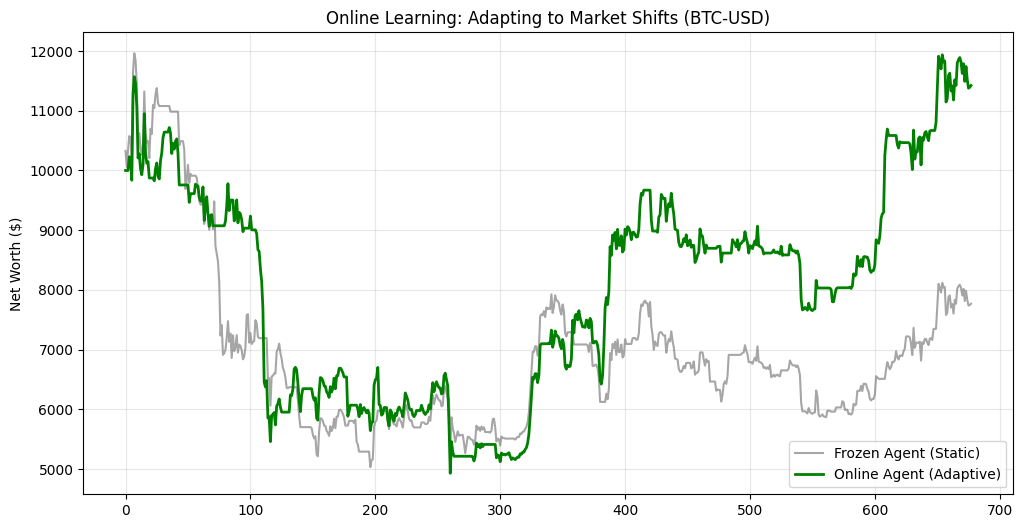

❄️ Frozen Return: -24.78%
🌱 Online Return: 14.24%


In [14]:
plt.figure(figsize=(12, 6))
plt.plot(frozen_curve, label='Frozen Agent (Static)', color='gray', alpha=0.7)
plt.plot(online_curve, label='Online Agent (Adaptive)', color='green', linewidth=2)
plt.title(f"Online Learning: Adapting to Market Shifts ({TICKER})")
plt.ylabel("Net Worth ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Performance Stats
frozen_ret = (frozen_curve[-1] / frozen_curve[0]) - 1
online_ret = (online_curve[-1] / online_curve[0]) - 1
print(f"❄️ Frozen Return: {frozen_ret*100:.2f}%")
print(f"🌱 Online Return: {online_ret*100:.2f}%")

In [15]:
# --- METRICS CALCULATION ---
metrics_data = []

# Dictionary to loop through both curves
results_map = {
    "Frozen (Dinosaur)": frozen_curve,
    "Online (Adaptive)": online_curve
}

for name, curve in results_map.items():
    series = pd.Series(curve)
    rets = series.pct_change().dropna()

    # 1. Total Return
    total_ret = (series.iloc[-1] / series.iloc[0]) - 1

    # 2. Annualized Volatility (Crypto markets = 365 days)
    vol = rets.std() * np.sqrt(365)

    # 3. Sharpe Ratio
    sharpe = (rets.mean() / rets.std()) * np.sqrt(365) if vol > 0 else 0

    # 4. Sortino Ratio (Penalize only downside volatility)
    neg_rets = rets[rets < 0]
    downside_std = neg_rets.std() * np.sqrt(365) if len(neg_rets) > 0 else 1.0
    sortino = (rets.mean() * 365) / downside_std if downside_std > 0 else 0

    # 5. Max Drawdown
    cum_ret = (1 + rets).cumprod()
    peak = cum_ret.cummax()
    dd = (cum_ret - peak) / peak
    max_dd = dd.min()

    # 6. Win Rate (Daily)
    win_rate = len(rets[rets > 0]) / len(rets)

    metrics_data.append({
        "Agent Type": name,
        "Total Return": f"{total_ret*100:.1f}%",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Sortino Ratio": f"{sortino:.2f}",
        "Max Drawdown": f"{max_dd*100:.1f}%",
        "Volatility": f"{vol*100:.1f}%",
        "Win Rate": f"{win_rate*100:.1f}%"
    })

# --- DISPLAY ---
print("\n" + "="*80)
print(f"📊 ONLINE LEARNING SHOWDOWN (2022-2024 Bear Market)")
print("="*80)
metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))
print("="*80)


📊 ONLINE LEARNING SHOWDOWN (2022-2024 Bear Market)
       Agent Type Total Return Sharpe Ratio Sortino Ratio Max Drawdown Volatility Win Rate
Frozen (Dinosaur)       -24.8%        -0.10         -0.13       -58.0%      46.1%    35.7%
Online (Adaptive)        14.2%         0.39          0.46       -57.4%      47.9%    36.9%


In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIG ---
# Assuming 'agent' is your trained PPOAgent and 'env' is your test environment
# Ensure you run this AFTER training an agent from previous steps.

def compute_saliency(agent, state_tensor):
    """
    Computes which features in the state were most important for the agent's decision.
    """
    agent.actor.zero_grad()
    state_tensor.requires_grad_()

    # 1. Forward Pass
    logits = agent.actor(state_tensor)

    # 2. Get the "winning" action
    action_idx = torch.argmax(logits)
    score = logits[0, action_idx]

    # 3. Backward Pass (Gradient of score w.r.t input)
    score.backward()

    # 4. Get Gradients (Absolute value = magnitude of importance)
    saliency = state_tensor.grad.data.abs().cpu().numpy()
    return saliency, action_idx.item()

def run_forensics(agent, env):
    print("🕵️ Running Forensic Analysis...")

    s, _ = env.reset()
    done = False

    # Metrics
    entropies = []
    saliency_maps = []
    actions = []
    net_worths = []

    while not done:
        # Prepare State
        s_val = s.astype(np.float32)
        s_t = torch.FloatTensor(s_val).flatten().unsqueeze(0).to(DEVICE)

        # 1. Capture Entropy (Confusion Level)
        with torch.no_grad():
            dist = torch.distributions.Categorical(agent.actor(s_t))
            entropy = dist.entropy().item()
            entropies.append(entropy)

        # 2. Capture Saliency (Why did it act?)
        # (This is expensive, so maybe run every 10 steps or on critical trades)
        sal, action = compute_saliency(agent, s_t)
        saliency_maps.append(sal.flatten()) # Flatten to 1D array of features
        actions.append(action)

        # Step
        ns, r, done, _, info = env.step(action)
        net_worths.append(info['net_worth'])
        s = ns

    return entropies, np.array(saliency_maps), actions, net_worths

# Run the diagnostics
entropies, saliency_matrix, actions, net_worths = run_forensics(agent, test_env)
print("✅ Forensics Complete.")

🕵️ Running Forensic Analysis...
✅ Forensics Complete.


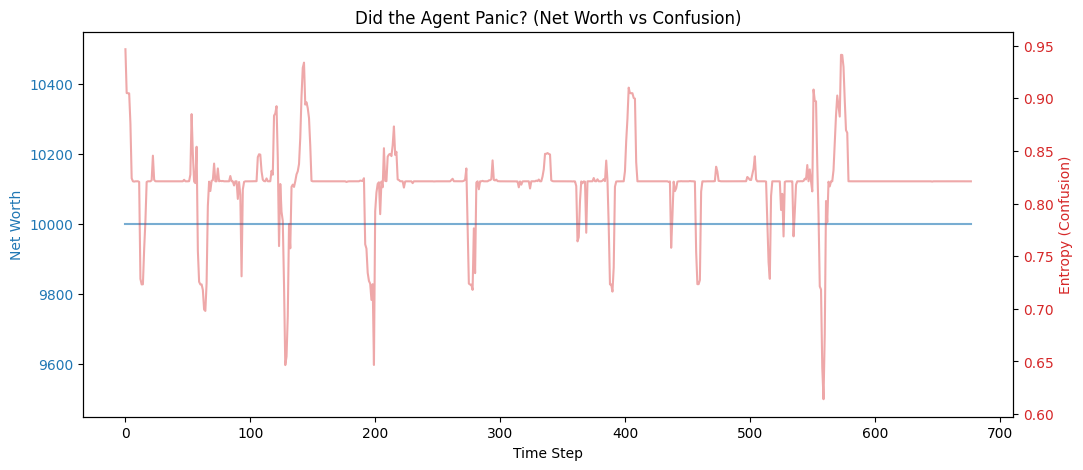

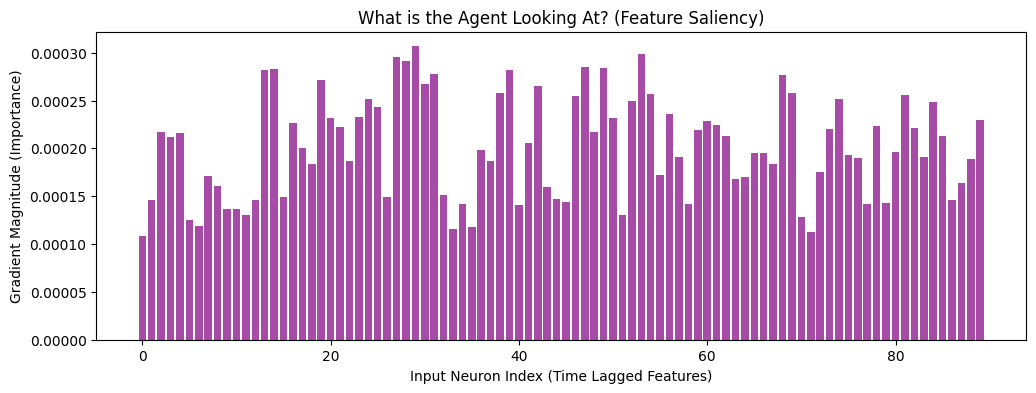

In [17]:
# --- PLOT 1: CONFIDENCE (Entropy) ---
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot Net Worth
color = 'tab:blue'
ax1.set_xlabel('Time Step')
ax1.set_ylabel('Net Worth', color=color)
ax1.plot(net_worths, color=color, alpha=0.6, label="Equity")
ax1.tick_params(axis='y', labelcolor=color)

# Plot Entropy (Uncertainty) on secondary axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Entropy (Confusion)', color=color)
ax2.plot(entropies, color=color, alpha=0.4, label="Agent Uncertainty")
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Did the Agent Panic? (Net Worth vs Confusion)")
plt.show()

# --- PLOT 2: FEATURE IMPORTANCE HEATMAP ---
# We average the saliency over time to see "Global Importance"
# We need to know what your features were. Assuming [Log_Ret, Vol, RSI] repeating
feature_names = ["Log_Ret", "Vol", "RSI"] * 30 # Flattened window
# Truncate if size mismatch (just for demo safety)
limit = min(len(feature_names), saliency_matrix.shape[1])

avg_saliency = np.mean(saliency_matrix[:, :limit], axis=0)

plt.figure(figsize=(12, 4))
plt.bar(range(limit), avg_saliency, color='purple', alpha=0.7)
plt.title("What is the Agent Looking At? (Feature Saliency)")
plt.xlabel("Input Neuron Index (Time Lagged Features)")
plt.ylabel("Gradient Magnitude (Importance)")
plt.show()

In [18]:
def stress_test(agent, df, noise_levels=[0.0, 0.01, 0.05]):
    results = {}

    for noise in noise_levels:
        print(f"⚡ Testing with {noise*100}% Noise Injection...")

        # Create Noisy Data
        noisy_df = df.copy()
        # Add Gaussian noise to 'Close' prices
        noisy_df['Close'] = noisy_df['Close'] * (1 + np.random.normal(0, noise, len(noisy_df)))
        # Re-calculate features based on noisy price
        noisy_df['Log_Ret'] = np.log(noisy_df['Close'] / noisy_df['Close'].shift(1)).fillna(0)

        # Run Env
        env = TradingEnv(noisy_df) # Assuming TradingEnv re-calculates internal logic
        s, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            with torch.no_grad():
                s_t = torch.FloatTensor(s.astype(np.float32)).flatten().unsqueeze(0).to(DEVICE)
                action = torch.argmax(agent.actor(s_t)).item()
            s, r, done, _, _ = env.step(action)
            total_reward += r

        results[f"Noise {noise*100}%"] = total_reward

    return results

# Run Stress Test
stress_results = stress_test(agent, test_df)

print("\n📊 STRESS TEST RESULTS (Total Reward)")
for k, v in stress_results.items():
    print(f"{k}: {v:.2f}")

⚡ Testing with 0.0% Noise Injection...
⚡ Testing with 1.0% Noise Injection...
⚡ Testing with 5.0% Noise Injection...

📊 STRESS TEST RESULTS (Total Reward)
Noise 0.0%: 0.00
Noise 1.0%: 0.00
Noise 5.0%: 0.00
